# Multi-Model Ensemble (MME) Regression Demo

Demonstrates the full MME workflow:
1. Download hindcasts from CDS → blob
2. Load and align model grids
3. Z-score normalization
4. Per-pixel Ridge regression with LOO CV
5. Skill maps vs baselines
6. Real-time prediction

In [79]:
%load_ext autoreload
%autoreload 2
%load_ext jupyter_black

import warnings

warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

from src.ensemble import download, load, normalize, regression, skill, pipeline
from src.datasources.era5 import open_era5_rasters

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black


## Configuration

In [4]:
ISSUE_MONTH = 4       # April
VALID_MONTHS = [7, 8, 9]  # JAS
STAGE = 'dev'

## Step 1 — Download hindcasts

Files have been downloaded manually and stored in blob at:
`pa-aa-bfa-drought/raw/cds/apr_issued/{centre}.grib`

Each file is April-issued, leadtimes 1–6, all available hindcast years for that centre.

In [5]:
# download.download_hindcasts(
#     issue_month=ISSUE_MONTH,
#     valid_months=VALID_MONTHS,
#     stage=STAGE,
#     overwrite=False,
# )

## Step 2 — Load & align forecast grids

In [142]:
dss = []
target_ds = None

for provider in [
    "ecmwf",
    "bom",
    "jma",
    "meteofrance",
    "ukmetoffice",
    "cmcc",
    "dwd",
]:
    filepath = f"data/apr_issued_jas_valid/{provider}.grib"
    ds_in = xr.load_dataset(filepath)
    print(provider)
    print(ds_in.longitude)
    ds_in_mean = (
        ds_in["tprate"]
        .mean(dim=["number", "step"])
        .groupby("time.year")
        .mean("time")
        .assign_coords(provider=provider)
    )
    if target_ds is None:
        target_ds = ds_in_mean  # use first provider as target grid
    else:
        ds_in_mean = ds_in_mean.interp(
            latitude=target_ds.latitude, longitude=target_ds.longitude
        )
    dss.append(ds_in_mean)

ds_combined = xr.concat(dss, dim="provider")

ecmwf
<xarray.DataArray 'longitude' (longitude: 10)> Size: 80B
array([-6.5, -5.5, -4.5, -3.5, -2.5, -1.5, -0.5,  0.5,  1.5,  2.5])
Coordinates:
    surface    float64 8B 0.0
  * longitude  (longitude) float64 80B -6.5 -5.5 -4.5 -3.5 ... -0.5 0.5 1.5 2.5
Attributes:
    units:          degrees_east
    standard_name:  longitude
    long_name:      longitude
bom
<xarray.DataArray 'longitude' (longitude: 10)> Size: 80B
array([-6.5, -5.5, -4.5, -3.5, -2.5, -1.5, -0.5,  0.5,  1.5,  2.5])
Coordinates:
    surface    float64 8B 0.0
  * longitude  (longitude) float64 80B -6.5 -5.5 -4.5 -3.5 ... -0.5 0.5 1.5 2.5
Attributes:
    units:          degrees_east
    standard_name:  longitude
    long_name:      longitude
jma
<xarray.DataArray 'longitude' (longitude: 8)> Size: 64B
array([-6.25, -5.  , -3.75, -2.5 , -1.25,  0.  ,  1.25,  2.5 ])
Coordinates:
    surface    float64 8B 0.0
  * longitude  (longitude) float64 64B -6.25 -5.0 -3.75 -2.5 -1.25 0.0 1.25 2.5
Attributes:
    units:          degre

In [70]:
ds_combined = xr.concat(dss, dim="provider")

In [71]:
reference_years = range(1993, 2016 + 1)

In [72]:
ds_combined

<xarray.DataArray 'tprate' (provider: 5, year: 45, latitude: 8, longitude: 10)> Size: 144kB
array([[[[2.93701312e-08, 2.99759755e-08, 2.77922183e-08, ...,
          2.76457293e-08, 2.60469584e-08, 2.22847056e-08],
         [5.04025941e-08, 4.87867524e-08, 4.96582153e-08, ...,
          3.82670748e-08, 3.68430229e-08, 3.43938389e-08],
         [6.69231923e-08, 6.54095018e-08, 6.58417889e-08, ...,
          4.99989241e-08, 4.67066990e-08, 4.50335200e-08],
         ...,
         [8.74099584e-08, 7.91651331e-08, 7.04206968e-08, ...,
          7.25237399e-08, 9.04995261e-08, 8.04741305e-08],
         [8.27341395e-08, 7.38112931e-08, 6.94053597e-08, ...,
          8.86225209e-08, 9.95619729e-08, 8.94127865e-08],
         [7.56459002e-08, 6.69807179e-08, 6.32242916e-08, ...,
          9.34373645e-08, 9.60643689e-08, 8.77227251e-08]],

        [[2.68704987e-08, 2.59388866e-08, 2.65392011e-08, ...,
          2.29990107e-08, 2.14188667e-08, 1.91086045e-08],
         [4.34604601e-08, 4.15730739e-08, 4.23124114e-08, ...,
          3.21306288e-08, 3.07328705e-08, 2.76321472e-08],
         [5.59711282e-08, 5.42002567e-08, 5.64503715e-08, ...,
          4.45705766e-08, 4.25352482e-08, 3.90110664e-08],
...
         [           nan,            nan,            nan, ...,
                     nan,            nan,            nan],
         [           nan,            nan,            nan, ...,
                     nan,            nan,            nan],
         [           nan,            nan,            nan, ...,
                     nan,            nan,            nan]],

        [[2.02300203e-08, 2.11657412e-08, 2.18506866e-08, ...,
          2.29900490e-08, 2.36341489e-08, 2.14974829e-08],
         [3.27495790e-08, 3.09514512e-08, 3.56160115e-08, ...,
          3.12534567e-08, 2.94761673e-08, 2.71991301e-08],
         [4.59478819e-08, 4.36450165e-08, 4.39005596e-08, ...,
          3.97788504e-08, 4.00466256e-08, 3.83098886e-08],
         ...,
         [9.86775532e-08, 8.82475746e-08, 7.34111083e-08, ...,
          5.10345082e-08, 5.38769882e-08, 6.04319297e-08],
         [1.10352360e-07, 8.69465211e-08, 6.81187871e-08, ...,
          5.30724762e-08, 5.65982461e-08, 5.52449002e-08],
         [9.34945277e-08, 7.86019001e-08, 5.80729953e-08, ...,
          4.97295112e-08, 5.07504119e-08, 4.52990001e-08]]]])
Coordinates:
  * latitude   (latitude) float64 64B 15.5 14.5 13.5 12.5 11.5 10.5 9.5 8.5
  * longitude  (longitude) float64 80B -6.5 -5.5 -4.5 -3.5 ... -0.5 0.5 1.5 2.5
  * year       (year) int64 360B 1981 1982 1983 1984 ... 2022 2023 2024 2025
    surface    float64 8B 0.0
  * provider   (provider) <U11 220B 'ecmwf' 'bom' ... 'ukmetoffice'

In [73]:
ds_combined_ref = ds_combined.sel(year=reference_years)

In [74]:
ds_combined_ref

<xarray.DataArray 'tprate' (provider: 5, year: 24, latitude: 8, longitude: 10)> Size: 77kB
array([[[[2.81055694e-08, 2.63658393e-08, 2.61281574e-08, ...,
          2.10729194e-08, 2.01141415e-08, 1.77586728e-08],
         [4.34688019e-08, 3.99079489e-08, 4.05550225e-08, ...,
          3.06876622e-08, 3.04987786e-08, 2.70045710e-08],
         [5.79582426e-08, 5.33648823e-08, 5.47841772e-08, ...,
          4.25963655e-08, 4.15885992e-08, 3.85117396e-08],
         ...,
         [8.03100804e-08, 7.21699323e-08, 6.56351560e-08, ...,
          6.42524327e-08, 8.59176126e-08, 7.68321726e-08],
         [7.86291423e-08, 6.90751278e-08, 6.46198188e-08, ...,
          8.56432578e-08, 9.86225999e-08, 8.82136106e-08],
         [7.69632393e-08, 6.84709320e-08, 6.21673308e-08, ...,
          9.51743786e-08, 9.59865645e-08, 8.42194012e-08]],

        [[2.76186611e-08, 2.48869760e-08, 2.50074663e-08, ...,
          2.70922715e-08, 2.44748666e-08, 2.23527117e-08],
         [4.45980319e-08, 4.09208596e-08, 4.06835667e-08, ...,
          3.76409552e-08, 3.33555121e-08, 3.16334372e-08],
         [6.19775804e-08, 5.85266378e-08, 5.86073519e-08, ...,
          4.67839207e-08, 4.46949464e-08, 4.20181685e-08],
...
         [8.68094077e-08, 7.79477105e-08, 6.41921076e-08, ...,
          4.80867435e-08, 5.16978034e-08, 5.76695030e-08],
         [9.95130023e-08, 8.16662578e-08, 6.52427161e-08, ...,
          5.39785496e-08, 5.90897962e-08, 5.94482579e-08],
         [8.83111397e-08, 7.68378499e-08, 5.88901479e-08, ...,
          5.47513856e-08, 5.82642699e-08, 5.26207664e-08]],

        [[1.46344910e-08, 1.57005253e-08, 1.62672507e-08, ...,
          2.15758380e-08, 2.20133050e-08, 1.95148573e-08],
         [2.54139536e-08, 2.50306336e-08, 3.00471292e-08, ...,
          2.85818196e-08, 2.60988955e-08, 2.48425476e-08],
         [3.76707234e-08, 3.80658669e-08, 3.92596462e-08, ...,
          3.54389584e-08, 3.47495295e-08, 3.48462983e-08],
         ...,
         [9.16433223e-08, 8.35684091e-08, 6.72774689e-08, ...,
          4.71224553e-08, 4.84616045e-08, 5.42330660e-08],
         [1.06421751e-07, 8.54473967e-08, 6.67667734e-08, ...,
          4.98193700e-08, 5.21696997e-08, 5.19582812e-08],
         [9.16486869e-08, 7.71838842e-08, 5.82141872e-08, ...,
          4.49837785e-08, 4.53758560e-08, 4.19645545e-08]]]])
Coordinates:
  * latitude   (latitude) float64 64B 15.5 14.5 13.5 12.5 11.5 10.5 9.5 8.5
  * longitude  (longitude) float64 80B -6.5 -5.5 -4.5 -3.5 ... -0.5 0.5 1.5 2.5
  * year       (year) int64 192B 1993 1994 1995 1996 ... 2013 2014 2015 2016
    surface    float64 8B 0.0
  * provider   (provider) <U11 220B 'ecmwf' 'bom' ... 'ukmetoffice'

In [75]:
has_data = ds_combined.notnull().any(dim=["latitude", "longitude"])

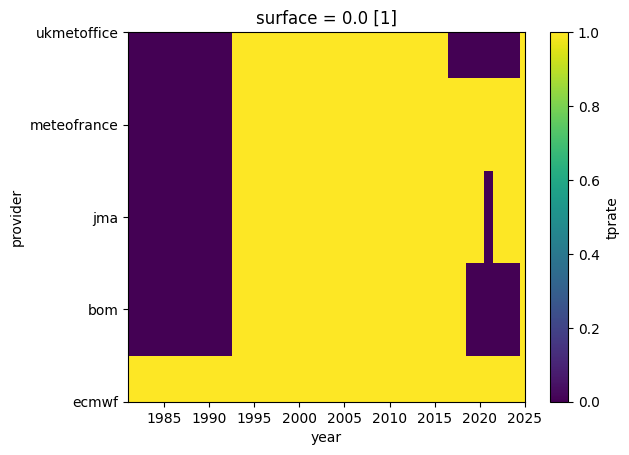

In [76]:
has_data.plot(x="year", y="provider")

In [78]:
ds_combined_ref

<xarray.DataArray 'tprate' (provider: 5, year: 24, latitude: 8, longitude: 10)> Size: 77kB
array([[[[2.81055694e-08, 2.63658393e-08, 2.61281574e-08, ...,
          2.10729194e-08, 2.01141415e-08, 1.77586728e-08],
         [4.34688019e-08, 3.99079489e-08, 4.05550225e-08, ...,
          3.06876622e-08, 3.04987786e-08, 2.70045710e-08],
         [5.79582426e-08, 5.33648823e-08, 5.47841772e-08, ...,
          4.25963655e-08, 4.15885992e-08, 3.85117396e-08],
         ...,
         [8.03100804e-08, 7.21699323e-08, 6.56351560e-08, ...,
          6.42524327e-08, 8.59176126e-08, 7.68321726e-08],
         [7.86291423e-08, 6.90751278e-08, 6.46198188e-08, ...,
          8.56432578e-08, 9.86225999e-08, 8.82136106e-08],
         [7.69632393e-08, 6.84709320e-08, 6.21673308e-08, ...,
          9.51743786e-08, 9.59865645e-08, 8.42194012e-08]],

        [[2.76186611e-08, 2.48869760e-08, 2.50074663e-08, ...,
          2.70922715e-08, 2.44748666e-08, 2.23527117e-08],
         [4.45980319e-08, 4.09208596e-08, 4.06835667e-08, ...,
          3.76409552e-08, 3.33555121e-08, 3.16334372e-08],
         [6.19775804e-08, 5.85266378e-08, 5.86073519e-08, ...,
          4.67839207e-08, 4.46949464e-08, 4.20181685e-08],
...
         [8.68094077e-08, 7.79477105e-08, 6.41921076e-08, ...,
          4.80867435e-08, 5.16978034e-08, 5.76695030e-08],
         [9.95130023e-08, 8.16662578e-08, 6.52427161e-08, ...,
          5.39785496e-08, 5.90897962e-08, 5.94482579e-08],
         [8.83111397e-08, 7.68378499e-08, 5.88901479e-08, ...,
          5.47513856e-08, 5.82642699e-08, 5.26207664e-08]],

        [[1.46344910e-08, 1.57005253e-08, 1.62672507e-08, ...,
          2.15758380e-08, 2.20133050e-08, 1.95148573e-08],
         [2.54139536e-08, 2.50306336e-08, 3.00471292e-08, ...,
          2.85818196e-08, 2.60988955e-08, 2.48425476e-08],
         [3.76707234e-08, 3.80658669e-08, 3.92596462e-08, ...,
          3.54389584e-08, 3.47495295e-08, 3.48462983e-08],
         ...,
         [9.16433223e-08, 8.35684091e-08, 6.72774689e-08, ...,
          4.71224553e-08, 4.84616045e-08, 5.42330660e-08],
         [1.06421751e-07, 8.54473967e-08, 6.67667734e-08, ...,
          4.98193700e-08, 5.21696997e-08, 5.19582812e-08],
         [9.16486869e-08, 7.71838842e-08, 5.82141872e-08, ...,
          4.49837785e-08, 4.53758560e-08, 4.19645545e-08]]]])
Coordinates:
  * latitude   (latitude) float64 64B 15.5 14.5 13.5 12.5 11.5 10.5 9.5 8.5
  * longitude  (longitude) float64 80B -6.5 -5.5 -4.5 -3.5 ... -0.5 0.5 1.5 2.5
  * year       (year) int64 192B 1993 1994 1995 1996 ... 2013 2014 2015 2016
    surface    float64 8B 0.0
  * provider   (provider) <U11 220B 'ecmwf' 'bom' ... 'ukmetoffice'

In [80]:
ds_era5 = open_era5_rasters(months=[7, 8, 9])

  0%|          | 0/44 [00:00<?, ?it/s]

In [85]:
ds_era5

<xarray.DataArray (year: 44, issued_month: 3, y: 721, x: 1440)> Size: 548MB
dask.array<concatenate, shape=(44, 3, 721, 1440), dtype=float32, chunksize=(1, 1, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * x             (x) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * y             (y) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
    spatial_ref   int64 8B 0
  * year          (year) int64 352B 1981 1982 1983 1984 ... 2021 2022 2023 2024
  * issued_month  (issued_month) int64 24B 7 8 9
Attributes: (12/16)
    AREA_OR_POINT:     Area
    averaging_period:  monthly
    date_issued:       None
    date_valid:        None
    download_date:     2024-09-26
    grid_resolution:   0.25
    ...                ...
    source:            ECMWF
    units:             mm/day
    version:           None
    year_issued:       None
    scale_factor:      1.0
    add_offset:        0.0

## Step 3 — Prep inputs

Rename dims on the forecast array, process ERA5 (sum JAS months, regrid to forecast grid), then restrict to shared years.

In [97]:
# Standardise dim names to match pipeline conventions
da_fc = ds_combined_ref.rename(
    {"latitude": "lat", "longitude": "lon", "provider": "model"}
)
. then 
# ERA5: sum JAS months, rename spatial dims, regrid to forecast grid
da_era5 = (
    ds_era5.sum("issued_month")
    .rename({"x": "lon", "y": "lat"})
    .interp(lat=da_fc.lat.values, lon=da_fc.lon.values, method="linear")
    .compute()
)

# Restrict to years present in both
shared_years = np.intersect1d(da_fc.year.values, da_era5.year.values)
da_fc = da_fc.sel(year=shared_years)
da_era5 = da_era5.sel(year=shared_years)

print("Forecast: ", da_fc)
print("ERA5:     ", da_era5)

Forecast:  <xarray.DataArray 'tprate' (model: 5, year: 24, lat: 8, lon: 10)> Size: 77kB
array([[[[2.81055694e-08, 2.63658393e-08, 2.61281574e-08, ...,
          2.10729194e-08, 2.01141415e-08, 1.77586728e-08],
         [4.34688019e-08, 3.99079489e-08, 4.05550225e-08, ...,
          3.06876622e-08, 3.04987786e-08, 2.70045710e-08],
         [5.79582426e-08, 5.33648823e-08, 5.47841772e-08, ...,
          4.25963655e-08, 4.15885992e-08, 3.85117396e-08],
         ...,
         [8.03100804e-08, 7.21699323e-08, 6.56351560e-08, ...,
          6.42524327e-08, 8.59176126e-08, 7.68321726e-08],
         [7.86291423e-08, 6.90751278e-08, 6.46198188e-08, ...,
          8.56432578e-08, 9.86225999e-08, 8.82136106e-08],
         [7.69632393e-08, 6.84709320e-08, 6.21673308e-08, ...,
          9.51743786e-08, 9.59865645e-08, 8.42194012e-08]],

        [[2.76186611e-08, 2.48869760e-08, 2.50074663e-08, ...,
          2.70922715e-08, 2.44748666e-08, 2.23527117e-08],
         [4.45980319e-08, 4.09208596e-08, 

## Step 4 — Z-score normalization

In [98]:
da_fc_z, X_clim_mean, X_clim_std = normalize.compute_zscores(da_fc, dim="year")
da_era5_z, y_clim_mean, y_clim_std = normalize.compute_zscores(
    da_era5, dim="year"
)

print(da_fc_z)
print(
    "Mean of z-scores over year (should ≈ 0):",
    float(da_fc_z.mean("year").mean()),
)

<xarray.DataArray 'tprate' (model: 5, year: 24, lat: 8, lon: 10)> Size: 77kB
array([[[[-0.41542663, -0.5308439 , -0.51138648, ..., -1.5232605 ,
          -1.50223591, -1.42232325],
         [-0.86236902, -1.10393668, -1.05134083, ..., -1.6803984 ,
          -1.40617704, -1.6738197 ],
         [-1.1249503 , -1.34213746, -1.41397654, ..., -1.53129897,
          -1.39728725, -1.56462802],
         ...,
         [-1.94462612, -1.87513852, -1.56165857, ..., -1.5388237 ,
          -1.37443599, -1.61983552],
         [-1.69606379, -1.53464773, -1.18499003, ..., -0.74359699,
          -0.89135083, -1.11240241],
         [-0.67758544, -0.75034369, -0.59398704, ..., -0.11029587,
          -0.61245532, -0.81411295]],

        [[-0.57891363, -1.0825371 , -0.92271848, ...,  0.63004836,
           0.22653679,  0.46454247],
         [-0.630307  , -0.87618652, -1.01921911, ...,  0.55195919,
          -0.3329316 , -0.15583105],
         [-0.41589384, -0.44715055, -0.67000707, ..., -0.4681642 ,
        

## Step 5 — Fit per-pixel Ridge regression

In [106]:
coefs, alpha, loo_preds = regression.fit_ridge_per_pixel(da_fc_z, da_era5_z)
print("Coefs: ", coefs)
print("Alphas:", alpha)

Coefs:  <xarray.DataArray 'coefs' (model: 5, lat: 8, lon: 10)> Size: 3kB
array([[[            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan],
        [            nan, -2.68461327e-01, -1.38019703e-04,
          3.21378120e-02,  1.14010046e-02,  2.73772924e-02,
          7.60889534e-02,  2.83962672e-01,  4.49127447e-01,
          2.09057536e-01],
        [            nan,  2.53096136e-04,  2.92882017e-02,
          3.14434186e-02,  2.48676036e-02,  2.60530917e-04,
          2.83329413e-02,  7.75342979e-02,  3.20321128e-02,
          2.46185050e-02],
        [            nan, -1.11034961e-02,  1.79903387e-02,
          2.84947713e-04, -1.39339771e-04,  8.74964767e-05,
          1.89463986e-06,  3.86391187e-04,  5.69787506e-02,
          3.09900806e-04],
        [            nan, -1.09148457e-01, -2.23822889e-01,
          6.38662422e-04,  2.03288762e-

## Step 6 — Skill maps

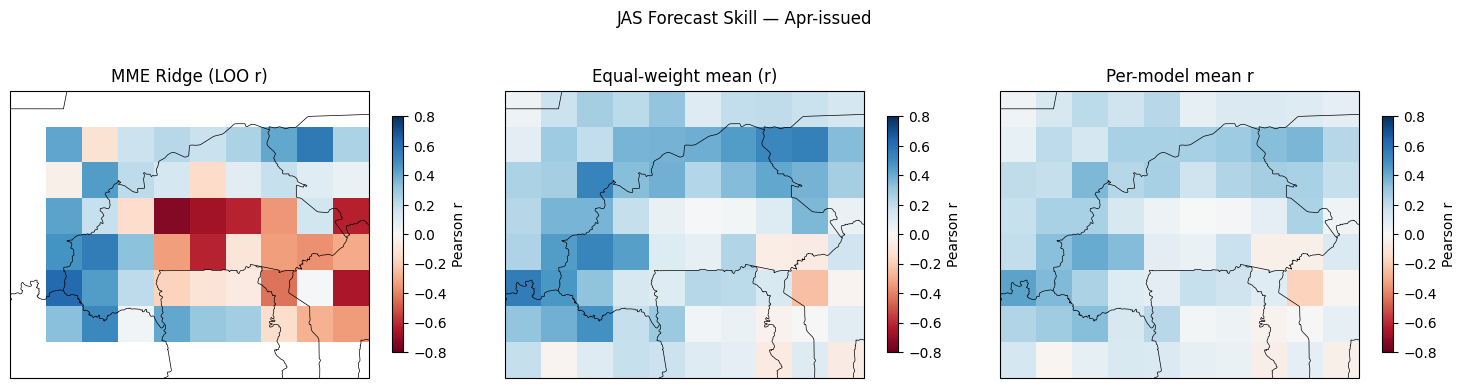

In [119]:
skill_maps = skill.skill_vs_baseline(loo_preds, da_fc_z, da_era5_z)
mme_r = skill_maps["mme_r"]
ew_r = skill_maps["equal_weight_r"]
per_model_r = skill_maps["per_model_r"]

fig, axes = plt.subplots(
    1, 3, figsize=(15, 4), subplot_kw={"projection": ccrs.PlateCarree()}
)
cmap, vmin, vmax = "RdBu", -0.8, 0.8

for ax, da, title in zip(
    axes,
    [mme_r, ew_r, per_model_r.mean("model")],
    ["MME Ridge (LOO r)", "Equal-weight mean (r)", "Per-model mean r"],
):
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    im = ax.pcolormesh(
        da.lon,
        da.lat,
        da.values,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree(),
    )
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.7, label="Pearson r")

plt.suptitle("JAS Forecast Skill — Apr-issued", y=1.02)
plt.tight_layout()
plt.show()

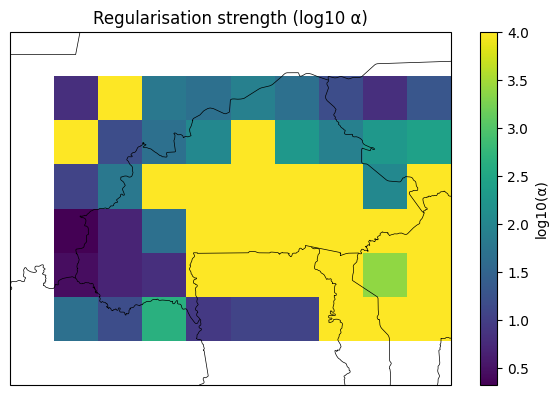

In [120]:
# Alpha map
fig, ax = plt.subplots(
    figsize=(6, 4), subplot_kw={"projection": ccrs.PlateCarree()}
)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
im = ax.pcolormesh(
    alpha.lon,
    alpha.lat,
    np.log10(alpha.values),
    cmap="viridis",
    transform=ccrs.PlateCarree(),
)
plt.colorbar(im, ax=ax, label="log10(α)")
ax.set_title("Regularisation strength (log10 α)")
plt.tight_layout()
plt.show()

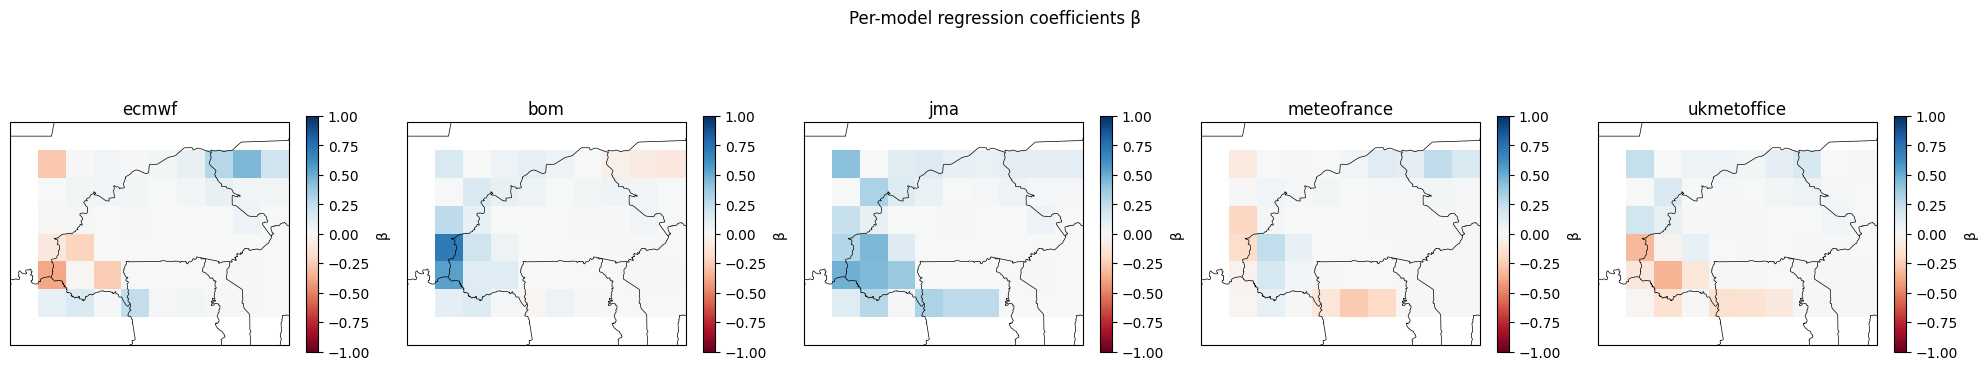

In [121]:
# Per-model coefficient maps
models = coefs.model.values
fig, axes = plt.subplots(
    1,
    len(models),
    figsize=(4 * len(models), 4),
    subplot_kw={"projection": ccrs.PlateCarree()},
)
if len(models) == 1:
    axes = [axes]

for ax, m in zip(axes, models):
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    c = coefs.sel(model=m)
    im = ax.pcolormesh(
        c.lon,
        c.lat,
        c.values,
        cmap="RdBu",
        vmin=-1,
        vmax=1,
        transform=ccrs.PlateCarree(),
    )
    ax.set_title(m)
    plt.colorbar(im, ax=ax, shrink=0.7, label="β")

plt.suptitle("Per-model regression coefficients β", y=1.02)
plt.tight_layout()
plt.show()

## Step 8 — Per-model skill & selected equal-weight ensemble

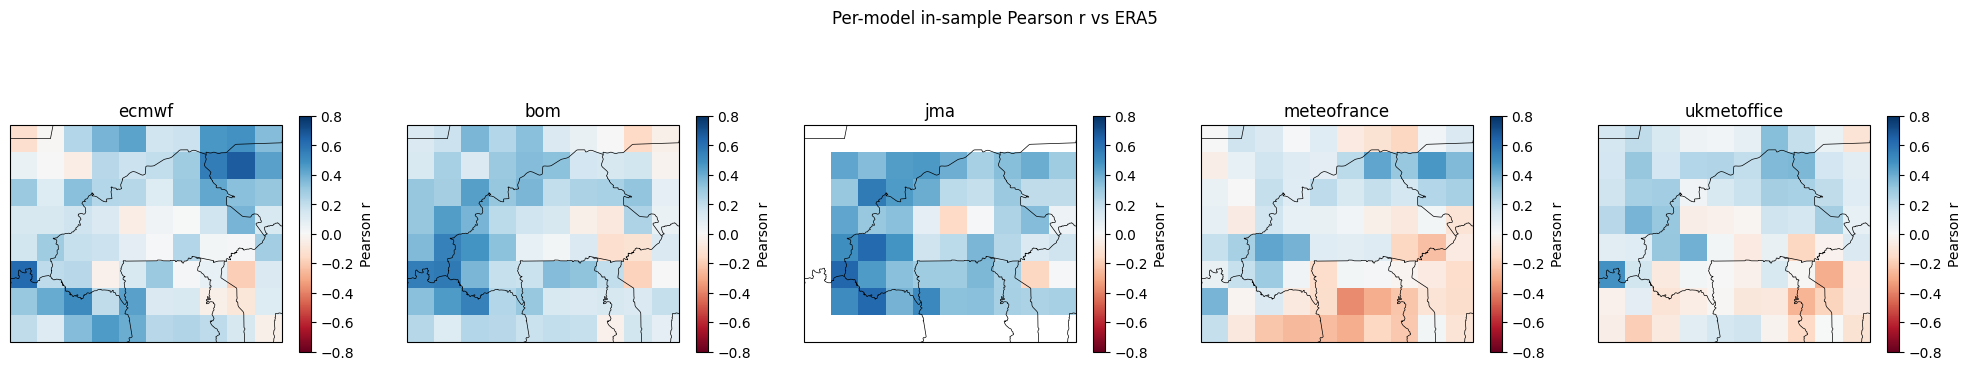

In [122]:
# Per-model correlation maps
models = da_fc_z.model.values
n = len(models)
fig, axes = plt.subplots(
    1, n, figsize=(4 * n, 4), subplot_kw={"projection": ccrs.PlateCarree()}
)
if n == 1:
    axes = [axes]

cmap, vmin, vmax = "RdBu", -0.8, 0.8
for ax, m in zip(axes, models):
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    r = per_model_r.sel(model=m)
    im = ax.pcolormesh(
        r.lon,
        r.lat,
        r.values,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree(),
    )
    ax.set_title(m)
    plt.colorbar(im, ax=ax, shrink=0.7, label="Pearson r")

plt.suptitle("Per-model in-sample Pearson r vs ERA5", y=1.02)
plt.tight_layout()
plt.show()

In [123]:
# Compute selected equal-weight ensemble (only models with r > 0 per pixel)
sel_ew, per_model_r = skill.selected_equal_weight(
    da_fc_z, da_era5_z, min_r=0.0
)
sel_ew_r = skill.pearson_r_map(sel_ew, da_era5_z)
n_selected = (per_model_r > 0).sum(dim="model")

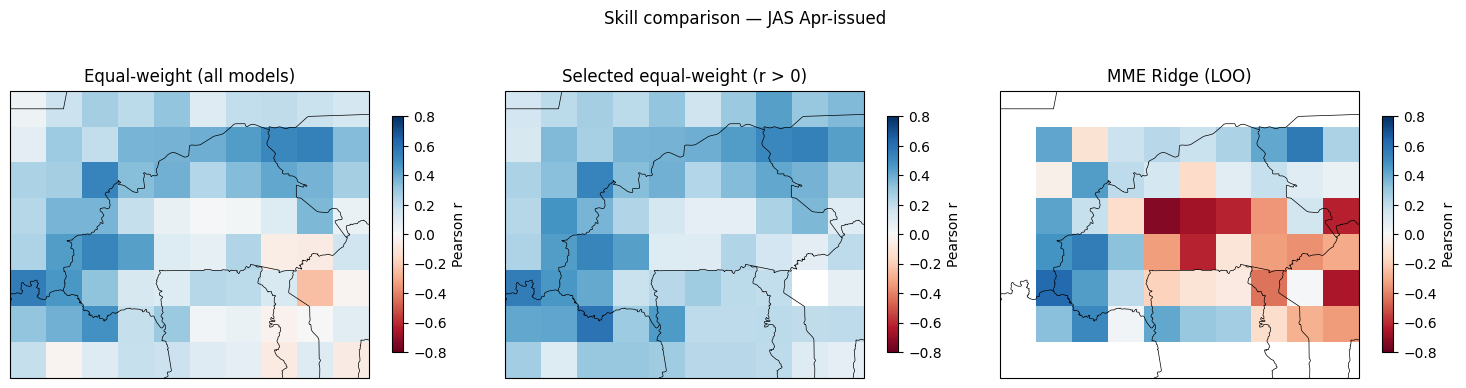

In [124]:
# Skill comparison: equal-weight vs selected equal-weight
fig, axes = plt.subplots(
    1, 3, figsize=(15, 4), subplot_kw={"projection": ccrs.PlateCarree()}
)
cmap, vmin, vmax = "RdBu", -0.8, 0.8

for ax, da, title in zip(
    axes,
    [ew_r, sel_ew_r, mme_r],
    [
        "Equal-weight (all models)",
        "Selected equal-weight (r > 0)",
        "MME Ridge (LOO)",
    ],
):
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    im = ax.pcolormesh(
        da.lon,
        da.lat,
        da.values,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree(),
    )
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.7, label="Pearson r")

plt.suptitle("Skill comparison — JAS Apr-issued", y=1.02)
plt.tight_layout()
plt.show()

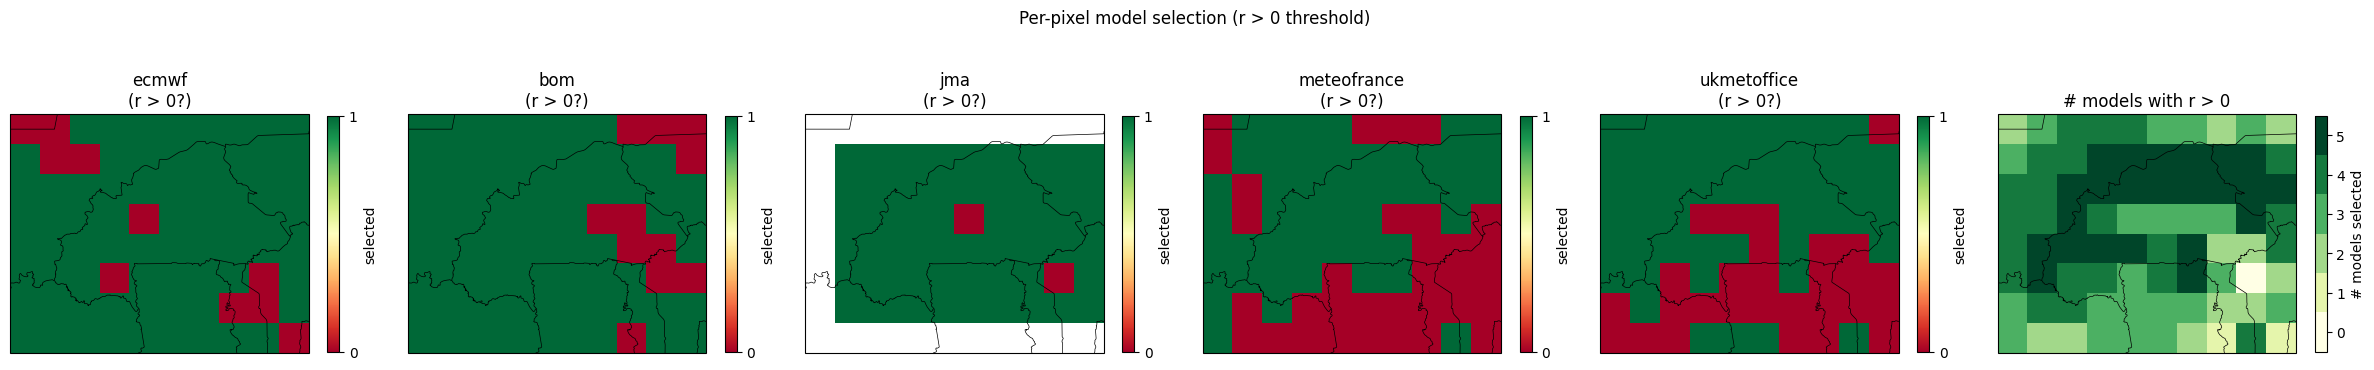

In [125]:
# Model selection map: which models pass r > 0 per pixel, and how many
models = da_fc_z.model.values
n = len(models)

fig, axes = plt.subplots(
    1,
    n + 1,
    figsize=(4 * (n + 1), 4),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

# Per-model boolean: is this model selected at each pixel?
for ax, m in zip(axes[:n], models):
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    selected_mask = (per_model_r.sel(model=m) > 0).astype(float)
    selected_mask = selected_mask.where(per_model_r.sel(model=m).notnull())
    im = ax.pcolormesh(
        selected_mask.lon,
        selected_mask.lat,
        selected_mask.values,
        cmap="RdYlGn",
        vmin=0,
        vmax=1,
        transform=ccrs.PlateCarree(),
    )
    ax.set_title(f"{m}\n(r > 0?)")
    plt.colorbar(im, ax=ax, shrink=0.7, ticks=[0, 1], label="selected")

# Count of selected models per pixel
ax = axes[-1]
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
cmap_count = plt.get_cmap("YlGn", n + 1)
im = ax.pcolormesh(
    n_selected.lon,
    n_selected.lat,
    n_selected.values.astype(float),
    cmap=cmap_count,
    vmin=-0.5,
    vmax=n + 0.5,
    transform=ccrs.PlateCarree(),
)
plt.colorbar(
    im, ax=ax, shrink=0.7, ticks=range(n + 1), label="# models selected"
)
ax.set_title("# models with r > 0")

plt.suptitle("Per-pixel model selection (r > 0 threshold)", y=1.02)
plt.tight_layout()
plt.show()

In [134]:
# Best-of: use Ridge LOO where it beats selected-EW, otherwise fall back to selected-EW
# Both are on equal footing: Ridge is evaluated LOO; selected-EW has no fitted
# parameters so its in-sample r == LOO r.
ridge_wins = mme_r > sel_ew_r  # (lat, lon) boolean
best_pred = loo_preds.where(ridge_wins, other=sel_ew)  # (year, lat, lon)
best_r = mme_r.where(ridge_wins, other=sel_ew_r)  # (lat, lon)

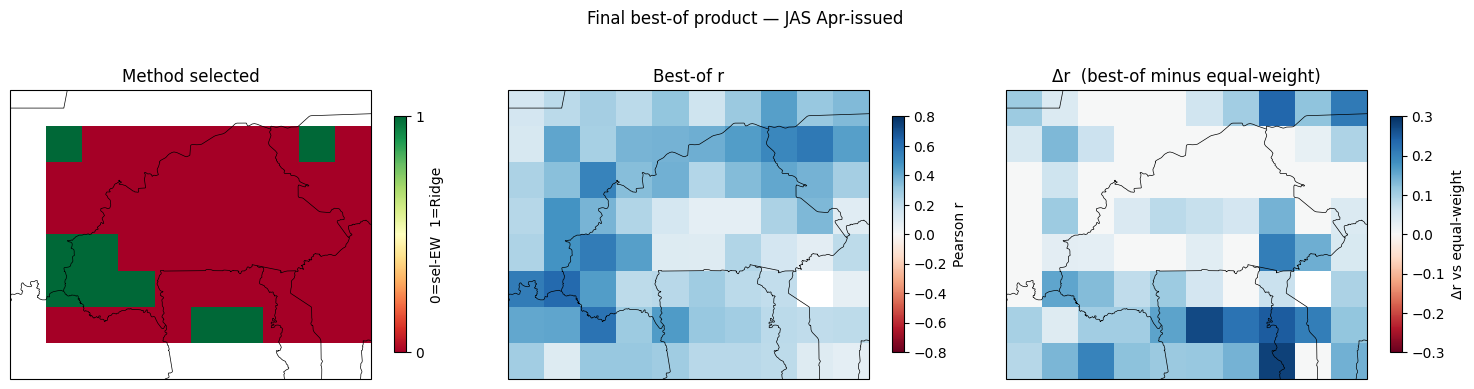

In [135]:
fig, axes = plt.subplots(
    1, 3, figsize=(15, 4), subplot_kw={"projection": ccrs.PlateCarree()}
)

# Left: which method was chosen
ax = axes[0]
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
method = ridge_wins.astype(float).where(mme_r.notnull())
im = ax.pcolormesh(
    method.lon,
    method.lat,
    method.values,
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    transform=ccrs.PlateCarree(),
)
plt.colorbar(im, ax=ax, shrink=0.7, ticks=[0, 1], label="0=sel-EW  1=Ridge")
ax.set_title("Method selected")

# Middle: best-of skill
ax = axes[1]
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
im = ax.pcolormesh(
    best_r.lon,
    best_r.lat,
    best_r.values,
    cmap="RdBu",
    vmin=-0.8,
    vmax=0.8,
    transform=ccrs.PlateCarree(),
)
plt.colorbar(im, ax=ax, shrink=0.7, label="Pearson r")
ax.set_title("Best-of r")

# Right: improvement over plain equal-weight
ax = axes[2]
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
delta = best_r - ew_r
im = ax.pcolormesh(
    delta.lon,
    delta.lat,
    delta.values,
    cmap="RdBu",
    vmin=-0.3,
    vmax=0.3,
    transform=ccrs.PlateCarree(),
)
plt.colorbar(im, ax=ax, shrink=0.7, label="Δr vs equal-weight")
ax.set_title("Δr  (best-of minus equal-weight)")

plt.suptitle("Final best-of product — JAS Apr-issued", y=1.02)
plt.tight_layout()
plt.show()

## Step 7 — Reliability scatter

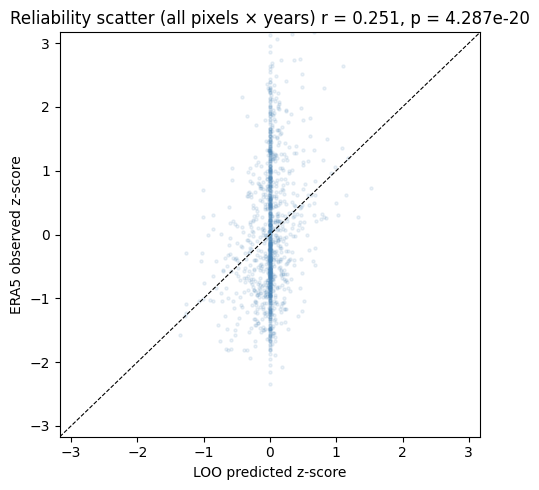

In [136]:
pred_flat = loo_preds.values.ravel()
obs_flat = da_era5_z.values.ravel()
mask = np.isfinite(pred_flat) & np.isfinite(obs_flat)

from scipy import stats

r, p = stats.pearsonr(pred_flat[mask], obs_flat[mask])

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(pred_flat[mask], obs_flat[mask], alpha=0.1, s=5, c="steelblue")
lim = max(np.abs([pred_flat[mask], obs_flat[mask]]).max(), 2)
ax.axline((0, 0), slope=1, color="k", lw=0.8, ls="--")
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel("LOO predicted z-score")
ax.set_ylabel("ERA5 observed z-score")
ax.set_title(
    f"Reliability scatter (all pixels × years) r = {r:.3f}, p = {p:.3e}"
)
plt.tight_layout()
plt.show()

In [137]:
import numpy as np
from src.ensemble.regression import (
    _fit_pixel,
    _loo_predictions,
    DEFAULT_ALPHAS,
)
from scipy.stats import pearsonr

X_z_t = da_fc_z.transpose("lat", "lon", "year", "model")
y_z_t = da_era5_z.transpose("lat", "lon", "year")

print("alpha stats:")
print(f"  median: {float(alpha.median()):.2f}")
print(f"  min:    {float(alpha.min()):.2f}")
print(f"  max:    {float(alpha.max()):.2f}")

for i in range(len(da_fc_z.lat)):
    for j in range(len(da_fc_z.lon)):
        xp = X_z_t.values[i, j]
        yp = y_z_t.values[i, j]
        valid = np.isfinite(yp) & np.all(np.isfinite(xp), axis=1)
        if valid.sum() < 10:
            continue
        xv, yv = xp[valid], yp[valid]
        c, a, loo = _fit_pixel(xp, yp, DEFAULT_ALPHAS)
        print(f"\nPixel ({i},{j}): selected alpha={a:.4f}")
        print(f"  coefs: {c}")
        print(
            f"  loo pred std: {np.nanstd(loo):.4f}  (obs std: {np.nanstd(yp):.4f})"
        )
        for test_alpha in [0.01, 0.1, 1, 10, 100, 1000]:
            lp = _loo_predictions(xv, yv, test_alpha)
            r, _ = pearsonr(lp, yv)
            print(f"  alpha={test_alpha:6.2f}: LOO r = {r:.3f}")
        break
    else:
        continue
    break

alpha stats:
  median: 193.07
  min:    2.12
  max:    10000.00

Pixel (1,1): selected alpha=6.5513
  coefs: [-0.26846133  0.15916168  0.41767726 -0.09478254  0.24002945]
  loo pred std: 0.4233  (obs std: 1.0000)
  alpha=  0.01: LOO r = 0.385
  alpha=  0.10: LOO r = 0.387
  alpha=  1.00: LOO r = 0.406
  alpha= 10.00: LOO r = 0.412
  alpha=100.00: LOO r = 0.280
  alpha=1000.00: LOO r = 0.227


## Step 9 — Lasso regression

In [138]:
lasso_coefs, lasso_alpha, lasso_loo = regression.fit_lasso_per_pixel(
    da_fc_z, da_era5_z
)
lasso_r = skill.pearson_r_map(lasso_loo, da_era5_z)
print(
    "Lasso alpha — median:",
    float(lasso_alpha.median()),
    "  min:",
    float(lasso_alpha.min()),
    "  max:",
    float(lasso_alpha.max()),
)
n_nonzero = (np.abs(lasso_coefs) > 1e-6).sum(dim="model")
print(
    "Non-zero coefs per pixel — median:",
    float(n_nonzero.median()),
    "  max:",
    float(n_nonzero.max()),
)

Lasso alpha — median: 10.0   min: 0.01151395399326447   max: 10.0
Non-zero coefs per pixel — median: 0.0   max: 5.0


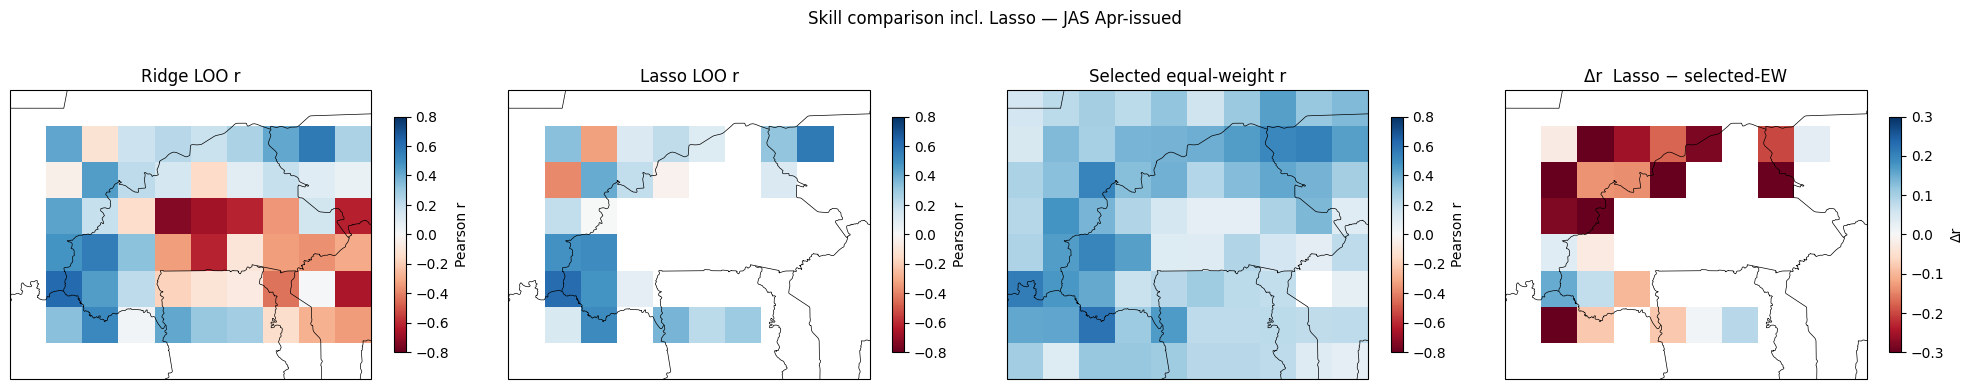

In [139]:
# 4-panel skill comparison: Ridge LOO, Lasso LOO, Selected-EW, Δr Lasso − selected-EW
fig, axes = plt.subplots(
    1, 4, figsize=(20, 4), subplot_kw={"projection": ccrs.PlateCarree()}
)
cmap, vmin, vmax = "RdBu", -0.8, 0.8

for ax, da, title in zip(
    axes[:3],
    [mme_r, lasso_r, sel_ew_r],
    ["Ridge LOO r", "Lasso LOO r", "Selected equal-weight r"],
):
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    im = ax.pcolormesh(
        da.lon,
        da.lat,
        da.values,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree(),
    )
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.7, label="Pearson r")

# Delta: Lasso minus selected equal-weight
ax = axes[3]
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
delta = lasso_r - sel_ew_r
im = ax.pcolormesh(
    delta.lon,
    delta.lat,
    delta.values,
    cmap="RdBu",
    vmin=-0.3,
    vmax=0.3,
    transform=ccrs.PlateCarree(),
)
plt.colorbar(im, ax=ax, shrink=0.7, label="Δr")
ax.set_title("Δr  Lasso − selected-EW")

plt.suptitle("Skill comparison incl. Lasso — JAS Apr-issued", y=1.02)
plt.tight_layout()
plt.show()